# Red Wine Quality Analysis

This notebook studies associations between physicochemical measurements and expert wine-quality scores. It separates **descriptive exploration** from **statistical inference** so that each result has a clear interpretation.

Important limitations:

- Quality is an **ordinal** score. Spearman rank correlation is therefore used as the primary association measure.
- This is observational data. Associations and regression coefficients are not causal effects.
- The data have no sample identifier. Exact duplicate rows may be repeated records or distinct wines with identical rounded values; both possibilities are examined.
- The confirmatory group comparison uses the project definition fixed in the README: low quality is `quality <= 5`, high quality is `quality >= 6`. Dichotomizing loses ordinal information, so score-level plots and correlations remain primary.


## 1. Setup and reproducibility

Dependencies are managed outside the notebook. No installation commands are run here. Restart the kernel and use **Run All** to reproduce the analysis from a clean state.


In [1]:
from pathlib import Path
import platform
import re
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import seaborn as sns
from scipy import stats

ALPHA = 0.05

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

print(f"Python: {platform.python_version()}")


Python: 3.14.6


In [2]:
SRC_DIR = next(candidate / "src" for candidate in [Path.cwd(), *Path.cwd().parents] if (candidate / "data" / "raw").is_dir())
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from data_cleaning import clean_column_names
from descriptive_statistics import descriptive_summary
from project_paths import find_project_root
from statistical_analysis import holm_adjust, spearman_table, welch_comparison

PROJECT_ROOT = find_project_root()
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures" / "RED_WINE_PLOTS"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "winequality-red.csv"
red_raw = pd.read_csv(DATA_PATH, sep=";")
red_raw.columns = clean_column_names(red_raw.columns)
print(f"Loaded {DATA_PATH}")
red_raw.head(10)


Loaded C:\Users\pc\Documents\GitHub\PROJECTS\WINE QUALITY ANALYSIS\data\raw\winequality-red.csv


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,ph,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5
6,7.9,0.60,0.06,1.6,0.069,15.0,59.0,0.9964,3.30,0.46,9.4,5
7,7.3,0.65,0.00,1.2,0.065,15.0,21.0,0.9946,3.39,0.47,10.0,7
8,7.8,0.58,0.02,2.0,0.073,9.0,18.0,0.9968,3.36,0.57,9.5,7
9,7.5,0.50,0.36,6.1,0.071,17.0,102.0,0.9978,3.35,0.80,10.5,5


## 2. Data validation and duplicate sensitivity

The validation below fails loudly if the schema, target scale, data types, or missingness differ from expectations. Exact duplicates are quantified but are not automatically called errors. The deduplicated frame is used as a conservative sensitivity dataset for statistical comparisons.


In [3]:
expected_columns = [
    "fixed_acidity", "volatile_acidity", "citric_acid", "residual_sugar",
    "chlorides", "free_sulfur_dioxide", "total_sulfur_dioxide",
    "density", "ph", "sulphates", "alcohol", "quality"
]
assert red_raw.columns.tolist() == expected_columns, "Unexpected dataset schema."
assert red_raw.isna().sum().sum() == 0, "Missing values require an explicit handling policy."
assert all(pd.api.types.is_numeric_dtype(red_raw[c]) for c in expected_columns), "All columns should be numeric."
assert red_raw["quality"].between(0, 10).all(), "Quality values fall outside the documented scale."

duplicate_count = int(red_raw.duplicated().sum())
red_unique = red_raw.drop_duplicates().reset_index(drop=True)
red_unique.to_csv(PROCESSED_DIR / "winequality-red-deduplicated.csv", index=False)
validation_summary = pd.Series({
    "rows_raw": len(red_raw),
    "columns": red_raw.shape[1],
    "missing_values": int(red_raw.isna().sum().sum()),
    "exact_duplicate_rows": duplicate_count,
    "duplicate_percentage": 100 * duplicate_count / len(red_raw),
    "rows_after_deduplication": len(red_unique),
})
validation_summary.round(2)


rows_raw                    1599.00
columns                       12.00
missing_values                 0.00
exact_duplicate_rows         240.00
duplicate_percentage          15.01
rows_after_deduplication    1359.00
dtype: float64

In [4]:
feature_columns = [c for c in expected_columns if c != "quality"]

descriptive_summary(red_raw).round(4)


,count,mean,std,variance,min,25%,50%,75%,max,skewness,excess_kurtosis
fixed_acidity,1599.0,8.3196,1.7411,3.0314,4.6000,7.1000,7.9000,9.2000,15.9000,0.9828,1.1321
volatile_acidity,1599.0,0.5278,0.1791,0.0321,0.1200,0.3900,0.5200,0.6400,1.5800,0.6716,1.2255
citric_acid,1599.0,0.2710,0.1948,0.0379,0.0000,0.0900,0.2600,0.4200,1.0000,0.3183,-0.7890
residual_sugar,1599.0,2.5388,1.4099,1.9879,0.9000,1.9000,2.2000,2.6000,15.5000,4.5407,28.6176
chlorides,1599.0,0.0875,0.0471,0.0022,0.0120,0.0700,0.0790,0.0900,0.6110,5.6803,41.7158
free_sulfur_dioxide,1599.0,15.8749,10.4602,109.4149,1.0000,7.0000,14.0000,21.0000,72.0000,1.2506,2.0236
total_sulfur_dioxide,1599.0,46.4678,32.8953,1082.1024,6.0000,22.0000,38.0000,62.0000,289.0000,1.5155,3.8098
density,1599.0,0.9967,0.0019,0.0000,0.9901,0.9956,0.9968,0.9978,1.0037,0.0713,0.9341
ph,1599.0,3.3111,0.1544,0.0238,2.7400,3.2100,3.3100,3.4000,4.0100,0.1937,0.8069
sulphates,1599.0,0.6581,0.1695,0.0287,0.3300,0.5500,0.6200,0.7300,2.0000,2.4287,11.7203


## 3. Outcome and feature distributions

Quality counts are shown directly because the target is discrete and ordinal. Feature histograms reveal skewness and possible outliers; these are not removed merely for being unusual. Measurement units follow the UCI dataset documentation and should be checked before scientific interpretation.


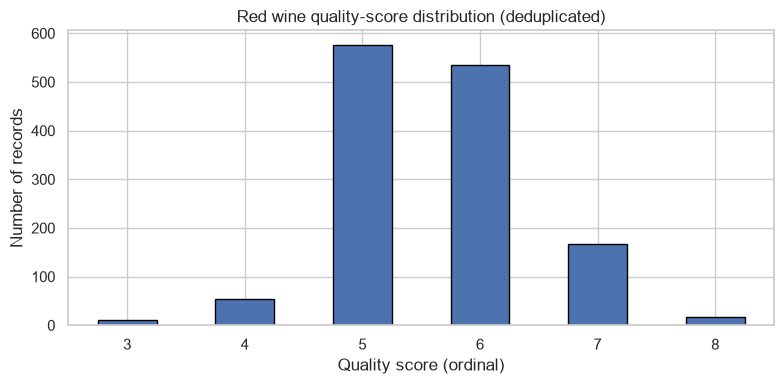

,count
quality,
3,10
4,53
5,577
6,535
7,167
8,17


In [5]:
quality_counts = red_unique["quality"].value_counts().sort_index()
ax = quality_counts.plot.bar(figsize=(8, 4), edgecolor="black")
ax.set(title="Red wine quality-score distribution (deduplicated)", xlabel="Quality score (ordinal)", ylabel="Number of records")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "quality_score_distribution.png", dpi=300, bbox_inches="tight")
plt.show()
quality_counts.to_frame("count")


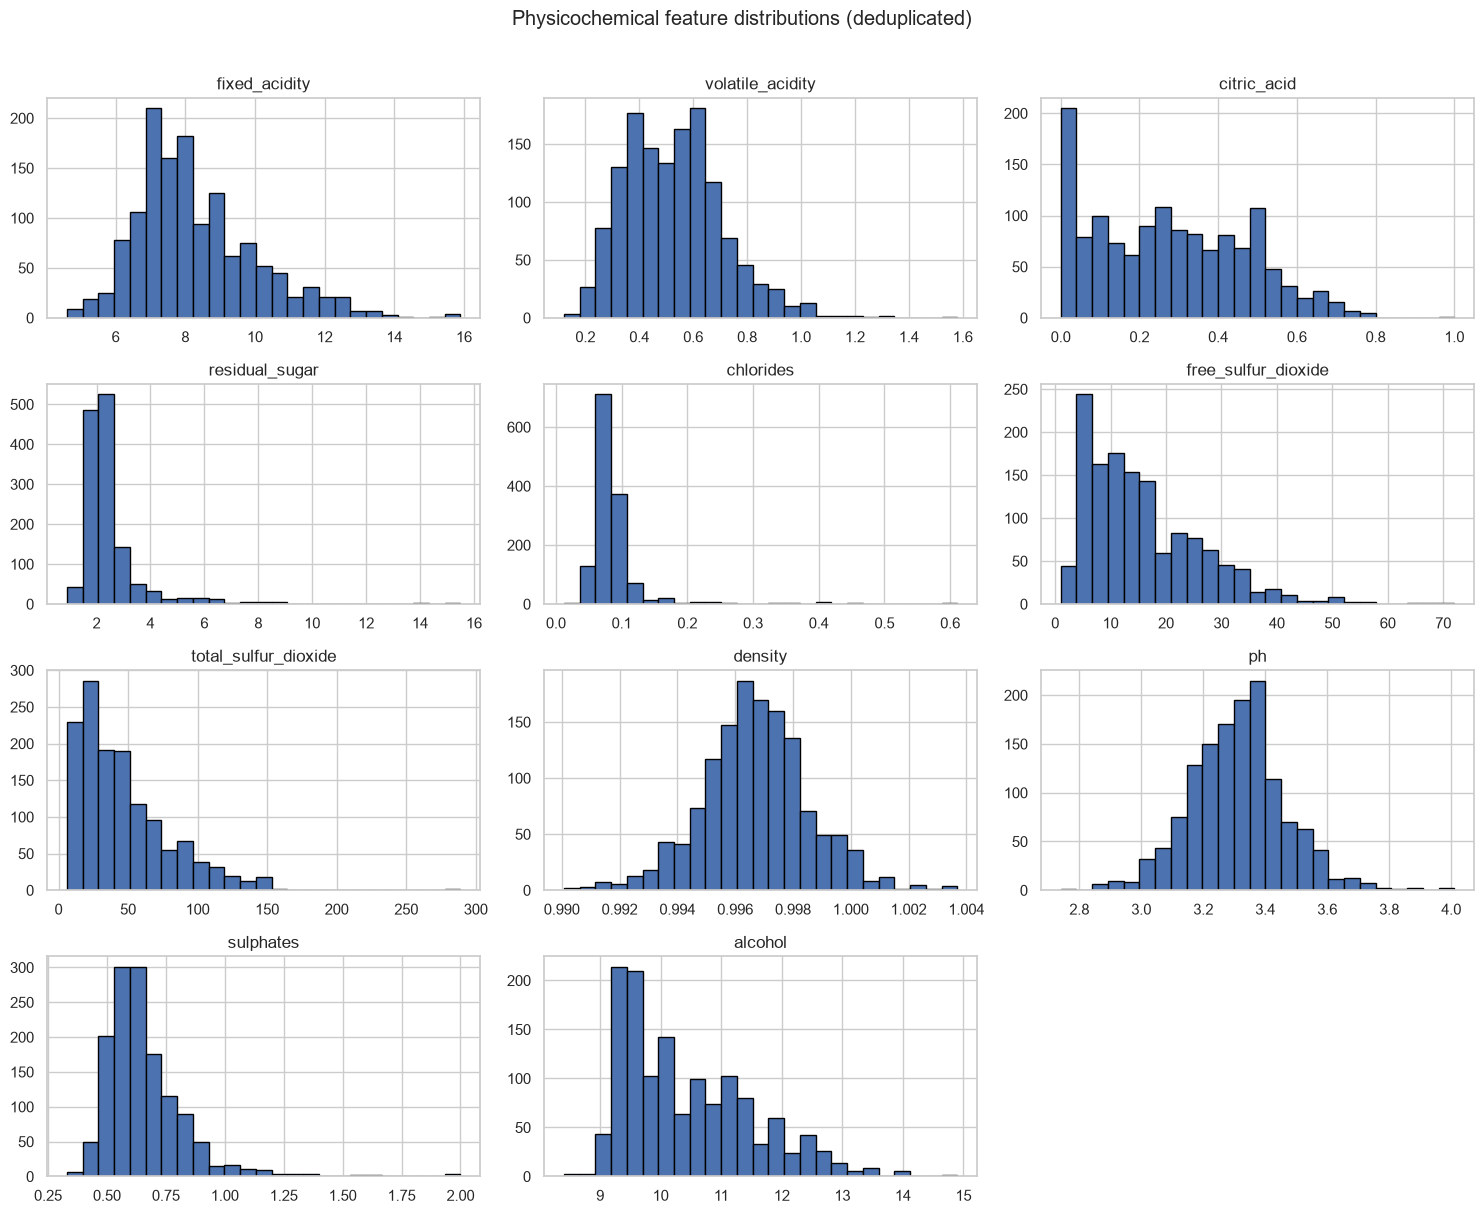

In [6]:
red_unique[feature_columns].hist(figsize=(15, 12), bins=25, edgecolor="black")
plt.suptitle("Physicochemical feature distributions (deduplicated)", y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "physicochemical_feature_distributions.png", dpi=300, bbox_inches="tight")
plt.show()


## 4. Exploratory ordinal association

Spearman's rank correlation is primary because quality is ordinal and feature relationships need not be linear. All eleven features are reported, not only the strongest-looking ones. Holm-adjusted p-values control the family-wise error rate across this exploratory table, but effect magnitude and uncertainty matter more than a significance label.


In [7]:
association_raw = spearman_table(red_raw, feature_columns).rename(columns={"spearman_rho": "rho_raw", "holm_p_value": "holm_p_raw"})
association_unique = spearman_table(red_unique, feature_columns).rename(columns={"spearman_rho": "rho_unique", "holm_p_value": "holm_p_unique"})
association_sensitivity = association_raw[["feature", "rho_raw", "holm_p_raw"]].merge(
    association_unique[["feature", "rho_unique", "holm_p_unique"]], on="feature"
).sort_values("rho_unique", key=abs, ascending=False)
association_sensitivity.style.format({"rho_raw": "{:.3f}", "holm_p_raw": "{:.3e}", "rho_unique": "{:.3f}", "holm_p_unique": "{:.3e}"})


,feature,rho_raw,holm_p_raw,rho_unique,holm_p_unique
0,alcohol,0.479,3.000e-91,0.488,3.562e-81
1,volatile_acidity,-0.381,2.735e-55,-0.387,6.542e-49
2,sulphates,0.377,3.130e-54,0.381,3.989e-47
3,citric_acid,0.213,4.927e-17,0.219,2.242e-15
5,chlorides,-0.190,1.130e-13,-0.204,1.962e-13
4,total_sulfur_dioxide,-0.197,1.433e-14,-0.197,1.566e-12
6,density,-0.177,4.959e-12,-0.184,3.778e-11
7,fixed_acidity,0.114,1.920e-05,0.112,1.472e-04
8,free_sulfur_dioxide,-0.057,6.865e-02,-0.059,9.104e-02
9,ph,-0.044,1.617e-01,-0.043,2.306e-01


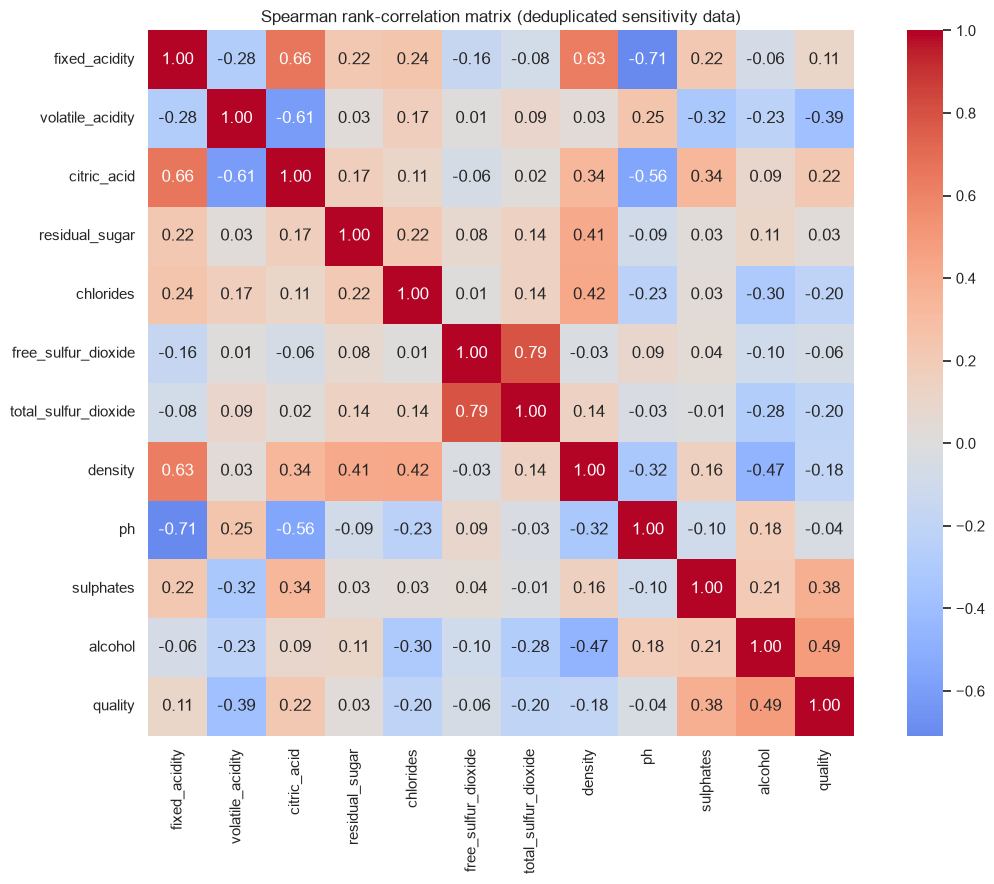

In [8]:
plt.figure(figsize=(12, 9))
sns.heatmap(red_unique[expected_columns].corr(method="spearman"), cmap="coolwarm", center=0, annot=True, fmt=".2f", square=True)
plt.title("Spearman rank-correlation matrix (deduplicated sensitivity data)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "spearman_correlation_matrix.png", dpi=300, bbox_inches="tight")
plt.show()


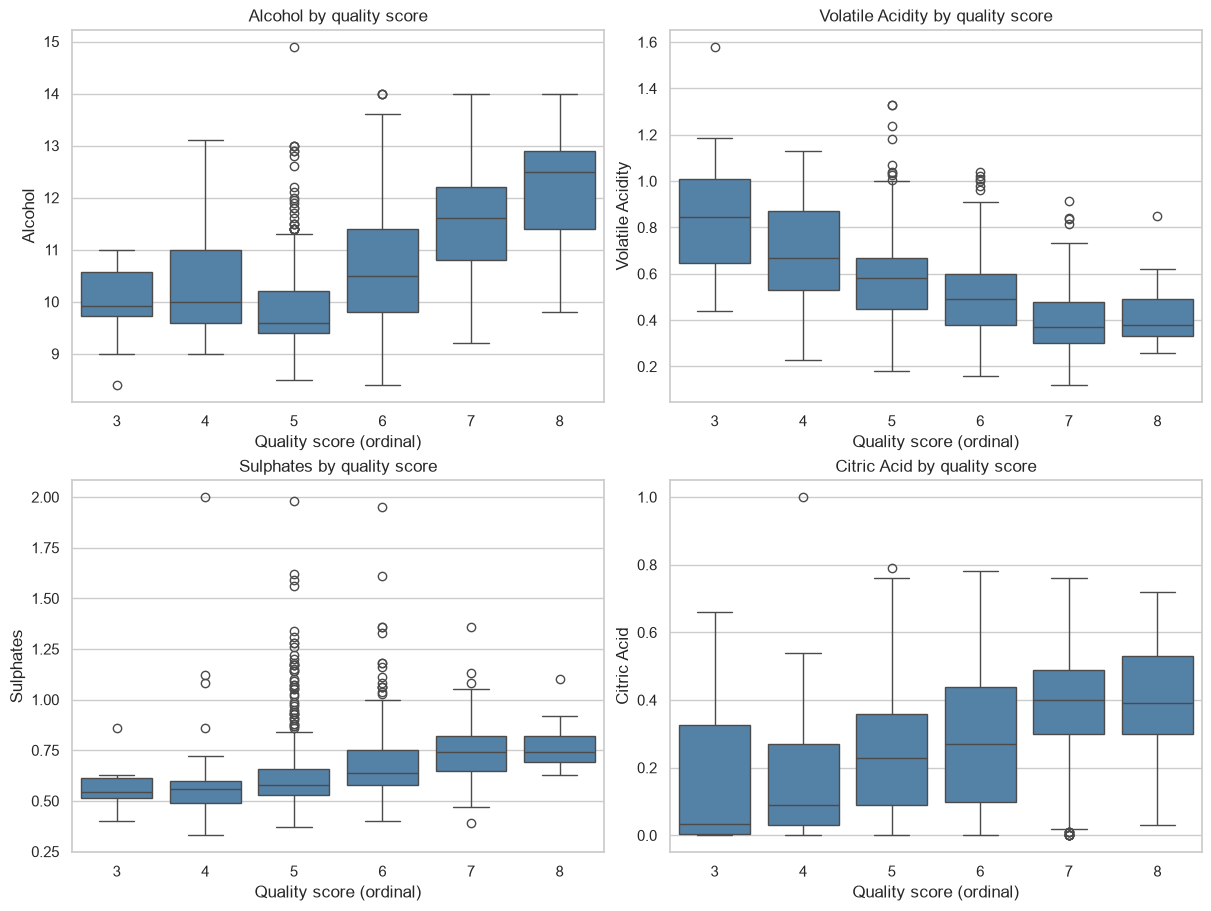

In [9]:
top_features_for_plot = association_unique.head(4)["feature"].tolist()
fig, axes = plt.subplots(2, 2, figsize=(12, 9), constrained_layout=True)
for feature, ax in zip(top_features_for_plot, axes.flat):
    sns.boxplot(data=red_unique, x="quality", y=feature, ax=ax, color="steelblue")
    ax.set(title=f"{feature.replace('_', ' ').title()} by quality score", xlabel="Quality score (ordinal)", ylabel=feature.replace('_', ' ').title())
fig.savefig(FIGURES_DIR / "top_features_by_quality_score.png", dpi=300, bbox_inches="tight")
plt.show()


## 5. Prespecified low-versus-high comparison

For continuity with the README, low quality is defined as scores 3-5 and high quality as scores 6-8. This threshold is a project convention, not a natural law. Welch's t-test estimates mean differences without assuming equal variances. We test **all eleven features**, adjust the p-values with Holm's method, and report pointwise (not multiplicity-adjusted) 95% confidence intervals and Hedges' *g*. Results use deduplicated data conservatively; the ordinal analysis above shows raw-versus-deduplicated sensitivity.


In [10]:
analysis_df = red_unique.copy()
analysis_df["quality_group"] = np.where(analysis_df["quality"] <= 5, "low (<=5)", "high (>=6)")
pd.crosstab(analysis_df["quality"], analysis_df["quality_group"], margins=True)


quality_group,high (>=6),low (<=5),All
quality,,,
3,0,10,10
4,0,53,53
5,0,577,577
6,535,0,535
7,167,0,167
8,17,0,17
All,719,640,1359


In [11]:
group_results = []
for feature in feature_columns:
    row = {"feature": feature}
    row.update(welch_comparison(
        analysis_df.loc[analysis_df["quality_group"] == "low (<=5)", feature],
        analysis_df.loc[analysis_df["quality_group"] == "high (>=6)", feature],
    ))
    group_results.append(row)

group_results = pd.DataFrame(group_results)
group_results["holm_p_value"] = holm_adjust(group_results["p_value"])
group_results["reject_at_0_05"] = group_results["holm_p_value"] < ALPHA
group_results = group_results.sort_values("holm_p_value").reset_index(drop=True)
group_results.style.format({
    "low_mean": "{:.3f}", "high_mean": "{:.3f}", "mean_difference_low_minus_high": "{:.3f}",
    "ci_95_low": "{:.3f}", "ci_95_high": "{:.3f}", "hedges_g": "{:.3f}",
    "welch_t": "{:.3f}", "p_value": "{:.3e}", "holm_p_value": "{:.3e}"
})


,feature,n_low,n_high,low_mean,high_mean,mean_difference_low_minus_high,ci_95_low,ci_95_high,hedges_g,welch_t,p_value,holm_p_value,reject_at_0_05
0,alcohol,640,719,9.921,10.888,-0.967,-1.068,-0.866,-0.998,-18.743,1.801e-69,1.981e-68,True
1,volatile_acidity,640,719,0.593,0.473,0.120,0.101,0.139,0.693,12.663,1.027e-34,1.027e-33,True
2,total_sulfur_dioxide,640,719,55.146,39.420,15.726,12.206,19.246,0.484,8.766,6.338e-18,5.704e-17,True
3,sulphates,640,719,0.620,0.693,-0.072,-0.090,-0.054,-0.433,-7.889,6.597e-15,5.278e-14,True
4,density,640,719,0.997,0.996,0.001,0.000,0.001,0.343,6.403,2.099e-10,1.469e-09,True
5,citric_acid,640,719,0.238,0.303,-0.066,-0.086,-0.045,-0.341,-6.302,3.967e-10,2.380e-09,True
6,chlorides,640,719,0.094,0.083,0.011,0.006,0.017,0.232,4.176,3.203e-05,1.602e-04,True
7,fixed_acidity,640,719,8.142,8.461,-0.319,-0.502,-0.137,-0.184,-3.430,6.225e-04,2.490e-03,True
8,free_sulfur_dioxide,640,719,16.659,15.211,1.448,0.331,2.565,0.139,2.543,1.110e-02,3.329e-02,True
9,residual_sugar,640,719,2.527,2.520,0.006,-0.138,0.150,0.005,0.087,9.303e-01,1.000e+00,False
